In [19]:

import os
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers
# from keras.preprocessing.image import ImageDataGenerator


In [20]:
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [21]:
devices=tf.config.experimental.list_physical_devices()
devices

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [22]:
IMG_SIZE = 128   # or whatever you trained with
BATCH_SIZE=32
train_ds, val_ds = tfds.load(
    "citrus_leaves",
    split=["train[:90%]", "train[10%:]"],
    as_supervised=True,
    data_dir="/app/data/tfds"
)
len(train_ds)


535

In [23]:
ds_info = tfds.builder("citrus_leaves", data_dir="/app/data/tfds").info
class_names = ds_info.features["label"].names
print(class_names)

['Black spot', 'canker', 'greening', 'healthy']


In [24]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)          # convert uint8 → float32
    # image = image / 255.0                   # normalize to [0,1]
    return image, label


In [25]:
train_ds_transformed = (
    train_ds
    .map(preprocess)
    .cache()
    .shuffle(1000)   # shuffle examples
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_transformed = (
    val_ds
    .map(preprocess)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [26]:

from matplotlib import pyplot as plt


def visualize_dataset(dataset, num_images=9):
    plt.figure(figsize=(8, 8))
    count = 0
    dataset_iter = dataset.unbatch().as_numpy_iterator()
    for image, label in dataset_iter:
        if image.dtype != "float32":
            image = image.astype("float32") / 255.0
        image = image.astype("float32") / 255.0

        plt.subplot(3, 3, count + 1)
        plt.imshow(image)
        plt.title(f"Label: {label}")
        plt.axis("off")
        count += 1
        if count >= num_images:
            break

    plt.show()


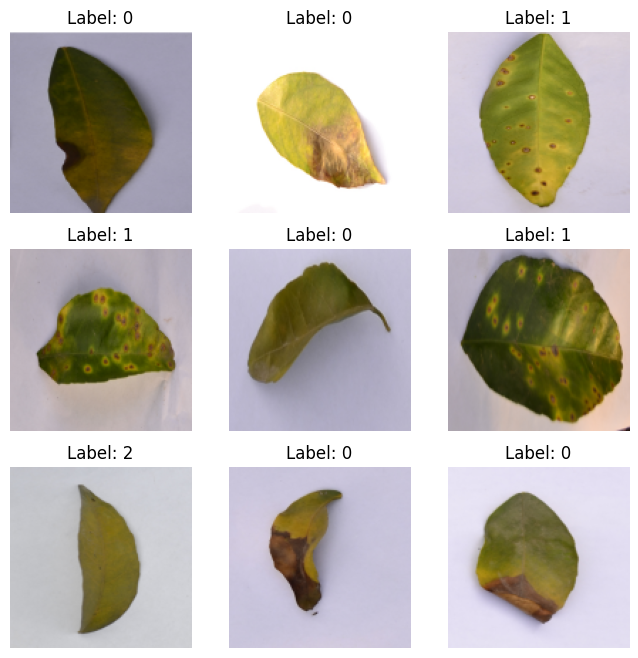

In [27]:

# Visualize
visualize_dataset(train_ds_transformed)



In [ ]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomContrast(0.2),
    keras.layers.RandomTranslation(0.1, 0.1),
])

In [29]:
base = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base.trainable = False 

In [30]:
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,  

    keras.layers.Lambda(
        tf.keras.applications.efficientnet.preprocess_input
    ),

    base,

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),

    keras.layers.Dense(128, activation="relu"),
    # keras.layers.Dropout(0.5),

    keras.layers.Dense(4, activation="softmax"),
])


In [31]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy']
)


In [32]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 128, 128, 3)       0         
                                                                 
 lambda_1 (Lambda)           (None, 128, 128, 3)       0         
                                                                 
 efficientnetv2-b0 (Functio  (None, 4, 4, 1280)        5919312   
 nal)                                                            
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_1 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                                      

In [33]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if (logs.get('accuracy') > 0.95 and logs.get('val_accuracy') > 0.95):
            if self.model:
                self.model.stop_training = True
            print("\n\nSufficient Metrics Reached!\n\n")


In [34]:
from random import seed


epochs=100
history=model.fit(
    train_ds_transformed,
    epochs=epochs,
    # batch_size=BATCH_SIZE,
    validation_data=val_ds_transformed,
    callbacks=myCallback()
)


Epoch 1/100


2026-02-12 08:40:39.735925: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_3/efficientnetv2-b0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


17/17 [==============================] - 11s 158ms/step - loss: 1.2514 - accuracy: 0.4916 - val_loss: 0.8397 - val_accuracy: 0.6243
Epoch 2/100
17/17 [==============================] - 1s 54ms/step - loss: 0.5749 - accuracy: 0.7776 - val_loss: 0.6802 - val_accuracy: 0.7234
Epoch 3/100
17/17 [==============================] - 1s 52ms/step - loss: 0.4052 - accuracy: 0.8486 - val_loss: 0.5898 - val_accuracy: 0.7813
Epoch 4/100
17/17 [==============================] - 1s 53ms/step - loss: 0.3414 - accuracy: 0.8692 - val_loss: 0.4916 - val_accuracy: 0.8673
Epoch 5/100
17/17 [==============================] - 1s 54ms/step - loss: 0.3085 - accuracy: 0.8860 - val_loss: 0.4208 - val_accuracy: 0.8822
Epoch 6/100
17/17 [==============================] - 1s 54ms/step - loss: 0.3029 - accuracy: 0.8860 - val_loss: 0.3502 - val_accuracy: 0.9047
Epoch 7/100
17/17 [==============================] - 1s 55ms/step - loss: 0.3390 - accuracy: 0.8935 - val_loss: 0.3236 - val_accuracy: 0.8991
Epoch 8/100
17/1

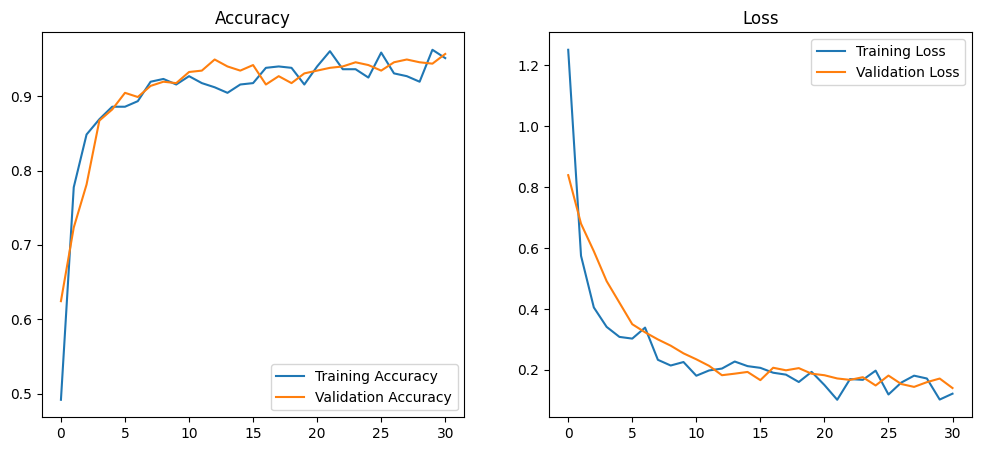

In [35]:
import matplotlib.pyplot as plt

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Loss")

plt.show()


In [36]:
model.save("citrus_efficientnet.h5")